# Cookie Cats A/B test: should the first gate move from level 30 to level 40?

**Cookie Cats** is a mobile puzzle game. At certain levels players hit a **gate**: they must wait or pay before continuing.
The team tested moving the first gate from **level 30 (control, A)** to **level 40 (treatment, B)**; 90,189 new players were
randomly assigned to one version.

**Decision to make:** keep the gate at 30, or move it to 40?

**Metrics (fixed before looking at the results):**

| Role | Metric | Why |
|---|---|---|
| **Primary** | 7-day retention | long-term engagement drives revenue |
| Secondary | 1-day retention | early experience |
| Guardrail | game rounds in the first 14 days | engagement should not collapse |

Significance level α = 0.05, two-sided.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
sys.path.insert(0, str(Path.cwd().parent))
from ab.stats import (srm_test, two_proportion_test, bootstrap_diff, bayesian_ab,
                      minimum_detectable_effect, required_sample_size, peeking_false_positive_rate)
sns.set_theme(style="whitegrid")
REPORTS = Path.cwd().parent / "reports"; REPORTS.mkdir(exist_ok=True)
df = pd.read_csv("../data/cookie_cats.csv")
A, B = df[df.version == "gate_30"], df[df.version == "gate_40"]
results = {}
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


## 1. Can we trust the experiment? Sanity checks

In [2]:
chi2, p_srm = srm_test(len(A), len(B))
results["n_a"], results["n_b"], results["srm_p"] = len(A), len(B), p_srm
print(f"Players: gate_30 = {len(A):,}, gate_40 = {len(B):,}  (duplicates: {df.userid.duplicated().sum()})")
print(f"Sample ratio mismatch test: chi2 = {chi2:.2f}, p = {p_srm:.4f}")

Players: gate_30 = 44,700, gate_40 = 45,489  (duplicates: 0)
Sample ratio mismatch test: chi2 = 6.90, p = 0.0086


**Sample ratio mismatch (SRM).** With a planned 50/50 split, 44,700 vs 45,489 players is a small imbalance
(49.6% / 50.4%). The p-value is below 0.05 but above **0.001, the threshold commonly used for SRM alerts** (the check
runs on every experiment, so a strict threshold avoids false alarms). We proceed, but note it as a limitation — in a
real company this would be raised with the team that owns the assignment logging.

In [3]:
print(df.sum_gamerounds.describe().round(1))
print("Largest values:", df.sum_gamerounds.nlargest(3).tolist())
outlier = df.loc[df.sum_gamerounds.idxmax()]
print(outlier.to_dict())

count    90189.0
mean        51.9
std        195.1
min          0.0
25%          5.0
50%         16.0
75%         51.0
max      49854.0
Name: sum_gamerounds, dtype: float64
Largest values: [49854, 2961, 2640]
{'userid': 6390605, 'version': 'gate_30', 'sum_gamerounds': 49854, 'retention_1': False, 'retention_7': True}


One player logged **49,854 rounds** in two weeks — 17× the next highest (2,961), i.e. ~3,500 rounds a day.
That is almost certainly a bot or a logging error. It barely affects the retention metrics (one player out of 45k)
but would distort any average of game rounds, so the guardrail analysis below uses **medians and rank-based tests**,
which are robust to it.

## 2. Primary metric: 7-day retention

In [4]:
def prop(col):
    return two_proportion_test(int(A[col].sum()), len(A), int(B[col].sum()), len(B))
r7 = prop("retention_7")
results["ret7"] = r7.__dict__
print(f"gate_30: {r7.rate_a:.2%}   gate_40: {r7.rate_b:.2%}")
print(f"Difference (40 - 30): {r7.diff*100:+.2f} pp, 95% CI [{r7.ci_low*100:+.2f}, {r7.ci_high*100:+.2f}] pp")
print(f"Relative change: {r7.rel_lift:+.1%}   z = {r7.z:.2f}, p = {r7.p_value:.4f}")

gate_30: 19.02%   gate_40: 18.20%
Difference (40 - 30): -0.82 pp, 95% CI [-1.33, -0.31] pp
Relative change: -4.3%   z = -3.16, p = 0.0016


Moving the gate to level 40 **lowers 7-day retention** by about 0.8 percentage points (≈4% relative), and the
confidence interval lies entirely below zero: the drop is statistically significant.

## 3. Secondary metric: 1-day retention

In [5]:
r1 = prop("retention_1")
results["ret1"] = r1.__dict__
print(f"gate_30: {r1.rate_a:.2%}   gate_40: {r1.rate_b:.2%}")
print(f"Difference: {r1.diff*100:+.2f} pp, 95% CI [{r1.ci_low*100:+.2f}, {r1.ci_high*100:+.2f}] pp, p = {r1.p_value:.4f}")

gate_30: 44.82%   gate_40: 44.23%
Difference: -0.59 pp, 95% CI [-1.24, +0.06] pp, p = 0.0744


Day-1 retention is also slightly lower with the gate at 40, but the interval includes zero — **not significant**.
That is plausible: most players do not reach level 30 or 40 on their first day, so the gate can barely affect day 1.

## 4. A second opinion: bootstrap
Resampling players 10,000 times gives the distribution of the difference without relying on the normal approximation.

retention_1: -0.59 pp, bootstrap 95% CI [-1.24, +0.06]


retention_7: -0.82 pp, bootstrap 95% CI [-1.32, -0.33]


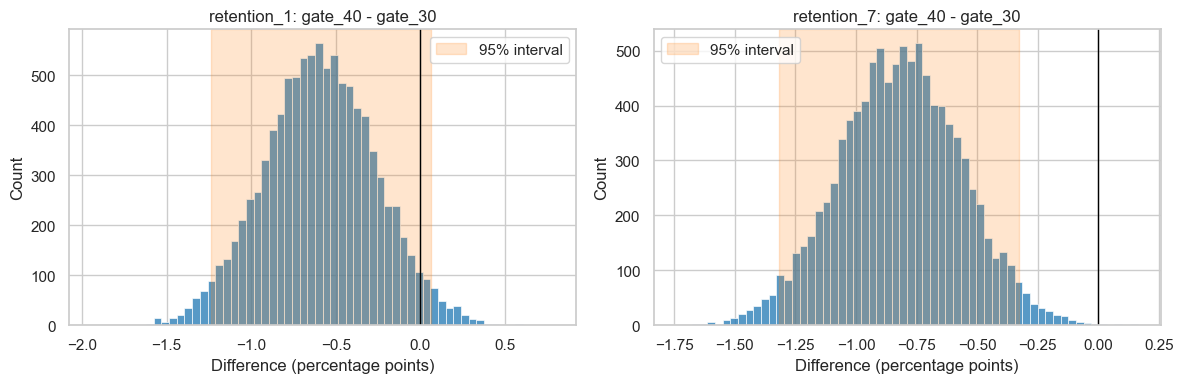

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
boot = {}
for i, col in enumerate(["retention_1", "retention_7"]):
    est, lo, hi, s = bootstrap_diff(A[col].astype(int).values, B[col].astype(int).values, n_boot=10_000)
    boot[col] = (est, lo, hi)
    sns.histplot(s * 100, ax=ax[i], bins=60, color="tab:blue")
    ax[i].axvline(0, color="black", lw=1)
    ax[i].axvspan(lo * 100, hi * 100, color="tab:orange", alpha=0.2, label="95% interval")
    ax[i].set(title=f"{col}: gate_40 - gate_30", xlabel="Difference (percentage points)")
    ax[i].legend()
    print(f"{col}: {est*100:+.2f} pp, bootstrap 95% CI [{lo*100:+.2f}, {hi*100:+.2f}]")
fig.tight_layout(); fig.savefig(REPORTS / "bootstrap_retention.png", dpi=120); plt.show()
results["bootstrap"] = boot

The bootstrap agrees with the z-test: 7-day retention clearly drops; 1-day retention is inconclusive.

## 5. Bayesian view: how likely is each version to be better?

In [7]:
bay = {}
for col in ["retention_1", "retention_7"]:
    b = bayesian_ab(int(A[col].sum()), len(A), int(B[col].sum()), len(B))
    bay[col] = {k: v for k, v in b.items() if k != "posterior_diff"}
    print(f"{col}: P(gate_30 better) = {1 - b['p_b_better']:.1%},  "
          f"expected loss if we choose gate_40 = {b['expected_loss_choose_b']*100:.3f} pp,  "
          f"if we choose gate_30 = {b['expected_loss_choose_a']*100:.4f} pp")
results["bayesian"] = bay

retention_1: P(gate_30 better) = 96.2%,  expected loss if we choose gate_40 = 0.595 pp,  if we choose gate_30 = 0.0050 pp
retention_7: P(gate_30 better) = 99.9%,  expected loss if we choose gate_40 = 0.819 pp,  if we choose gate_30 = 0.0001 pp


The Bayesian analysis answers the question managers actually ask — *"how sure are we?"* — directly: there is a
very high probability that level 30 gives better 7-day retention, and choosing level 40 carries a much larger expected
loss than keeping level 30.

## 6. Guardrail: engagement (game rounds)

In [8]:
u, p_mw = stats.mannwhitneyu(A.sum_gamerounds, B.sum_gamerounds, alternative="two-sided")
med = bootstrap_diff(A.sum_gamerounds.values, B.sum_gamerounds.values, stat=np.median, n_boot=5_000)
results["rounds"] = {"median_a": float(A.sum_gamerounds.median()), "median_b": float(B.sum_gamerounds.median()),
                     "mann_whitney_p": float(p_mw), "median_diff": med[0], "median_ci": [med[1], med[2]]}
print(f"Median rounds: gate_30 = {A.sum_gamerounds.median():.0f}, gate_40 = {B.sum_gamerounds.median():.0f}")
print(f"Median difference {med[0]:+.0f}, bootstrap 95% CI [{med[1]:+.0f}, {med[2]:+.0f}];  Mann-Whitney p = {p_mw:.3f}")

Median rounds: gate_30 = 17, gate_40 = 16
Median difference -1, bootstrap 95% CI [-1, +0];  Mann-Whitney p = 0.050


Game rounds are **borderline**: the median is one round lower with the gate at 40 and the rank-based test gives
p ≈ 0.05 — right at the threshold, and **not significant after correcting for multiple tests** (next section). If
anything it points the same way as retention: the later gate does not increase engagement.

## 7. Three metrics, one decision: correcting for multiple tests

In [9]:
pvals = [r7.p_value, r1.p_value, p_mw]
reject, p_holm, _, _ = multipletests(pvals, alpha=0.05, method="holm")
results["holm"] = dict(zip(["retention_7", "retention_1", "game_rounds"], [float(x) for x in p_holm]))
pd.DataFrame({"metric": ["retention_7 (primary)", "retention_1", "game_rounds"], "raw p": pvals,
              "Holm-adjusted p": p_holm, "significant": reject}).round(4)

,metric,raw p,Holm-adjusted p,significant
0,retention_7 (primary),0.0016,0.0047,True
1,retention_1,0.0744,0.1004,False
2,game_rounds,0.0502,0.1004,False


Testing three metrics raises the chance of a false alarm. After the **Holm correction**, 7-day retention is still significant; the conclusion does not change.

## 8. Was the test big enough? Power and minimum detectable effect

In [10]:
n = min(len(A), len(B))
mde = minimum_detectable_effect(r7.rate_a, n)
need = required_sample_size(r7.rate_a, 0.005)
results["mde_ret7_pp"] = mde * 100; results["n_needed_for_0_5pp"] = need
print(f"With {n:,} players per group, the smallest 7-day-retention change detectable with 80% power is {mde*100:.2f} pp.")
print(f"The observed change ({abs(r7.diff)*100:.2f} pp) is above that, so the test was adequately powered.")
print(f"Detecting a 0.5 pp change would need {need:,} players per group.")

With 44,700 players per group, the smallest 7-day-retention change detectable with 80% power is 0.74 pp.
The observed change (0.82 pp) is above that, so the test was adequately powered.
Detecting a 0.5 pp change would need 97,679 players per group.


We report the **minimum detectable effect** rather than "observed power" — observed power is just a restatement of
the p-value and is a common mistake.

## 9. Why you must not stop a test early: the peeking problem

Simulated A/A tests (no real difference): false-positive rate testing once = 5.7%, checking 20 times and stopping at the first p < 0.05 = 25.7%


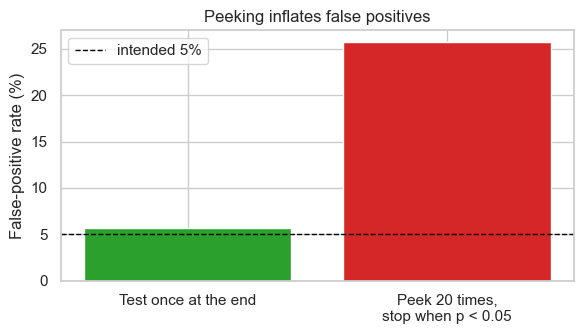

In [11]:
fixed, peek = peeking_false_positive_rate(p=0.19, n_per_group=20_000, n_looks=20, n_sims=2_000)
results["peeking"] = {"fixed": fixed, "peeking": peek}
print(f"Simulated A/A tests (no real difference): false-positive rate testing once = {fixed:.1%}, "
      f"checking 20 times and stopping at the first p < 0.05 = {peek:.1%}")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(["Test once at the end", "Peek 20 times,\nstop when p < 0.05"], [fixed * 100, peek * 100], color=["tab:green", "tab:red"])
ax.axhline(5, color="black", ls="--", lw=1, label="intended 5%")
ax.set(ylabel="False-positive rate (%)", title="Peeking inflates false positives")
ax.legend(); fig.tight_layout(); fig.savefig(REPORTS / "peeking.png", dpi=120); plt.show()

Checking results repeatedly and stopping as soon as they look significant multiplies false alarms, even when there
is no real effect. The fix is to fix the sample size in advance (as here) or use sequential methods designed for peeking.

## 10. Recommendation

In [12]:
lost = -r7.diff * 100_000
results["retained_players_lost_per_100k"] = lost
print(f"For every 100,000 new players, moving the gate to level 40 would mean about {lost:,.0f} fewer players still active after a week.")
(REPORTS / "results.json").write_text(json.dumps(results, indent=2, default=float))

For every 100,000 new players, moving the gate to level 40 would mean about 820 fewer players still active after a week.


1923

### ✅ Keep the gate at level 30.

- **7-day retention** — the primary metric — is **significantly lower** with the gate at level 40 (z-test, bootstrap and
  Bayesian analysis agree, and it survives the multiple-testing correction).
- 1-day retention and engagement (game rounds) show **no significant gain** for level 40 (both lean slightly worse), so nothing offsets the loss.
- The likely mechanism: an earlier gate forces a break, which may keep the game from feeling repetitive (hedonic adaptation).

**Limitations.** A mild (not alert-level) sample ratio imbalance; one extreme outlier handled with robust statistics;
retention is measured over two weeks only, so long-term revenue effects are not observed.